# Standardize time axes
## Overview
The main analysis focuses on the two TSI reconstructions (VIEIRA11, WU18), and the two temperature targets from the main analysis (ERB22 global mean, ALLEY00/GISP2), and the supplemental analysis considers Greenland temperature and $\delta^{18}$O series (Seierstad14, Martin24, Döring22) to test robustness of the ALLEY00 results, and output from a Holocene GCM run forced with constant TSI (Tian22) as a check on whether CCM can be fooled into detecting influence that isn't there.

**Goal**: This notebook puts every source record the paper uses onto one common decadal timeaxis.

**Reasoning**: CCM requires source time series to be evenly and identically spaced. The simplest way to achieve this was to align all timeseries to the decadal spacing already adopted by Wu et al, 2018 (TSI) and Erb et al, 2022. (GMST).

**Outline**:
Each source arrives with its own units, calendar convention, and native resolution. This notebook's job is to negotiate getting them all onto a shared, ascending, years-relative-to-1950 decadal time axis and saved to master_data, and generate a corresponding set of surrogates and save them to master_surrogates.

- Section 1: handles reading in data and aligning time to "calendar years BP (before 1950)"
- Section 2: decadal averaging and shared time axis
- Section 3: surrogates


In [48]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np


In [49]:
import xarray as xr

from cedarkit.core.data_var import VarObject

In [50]:
var_objects = {}

def make_real_var_object(var_id, source_frame, time_col, value_col='value'):
    # Keep source ages as positive BP while Pyleoclim interpolates and bins.
    required_columns = {time_col, value_col}
    missing_columns = required_columns.difference(source_frame.columns)
    if missing_columns:
        raise ValueError(f"{var_id} is missing standardized columns: {missing_columns}")

    source_frame = source_frame[[time_col, value_col]].sort_values(time_col).reset_index(drop=True)
    var_object = VarObject(None, var_id, proj_stem)
    var_object.ts_type = "real"
    var_object.set_col_name()
    var_object.ts = source_frame.rename(columns={
        time_col: var_object.real_ts_time,
        value_col: var_object.col_name,
    }).copy()
    var_object.time_var = var_object.real_ts_time
    return var_object


### Time convention

Ages stay in positive years BP while the data are interpolated and binned into
decades. Once that's done, the axis flips to negative years relative to 1950,
sorted oldest to youngest.


These bounds (205–7945 yr BP, roughly 1745 CE–6100 BCE) match the paper's analysis
window: *"we consider the interval ∼6100 BCE to ∼1750 CE, in an effort to target a
period believed to be minimally affected by residual fluctuations from the
deglaciation and early influence of anthropogenic emissions"* (Experimental Design:
Data). Decade-level resolution matches the coarsest of the four source
reconstructions (WU18) and keeps every dyad on the same evenly spaced grid — which
CCM's current implementation needs.


In [51]:
# Positive BP axis used only for Pyleoclim interpolation and Wu-centred bins.
start_time, end_time = 205, 7945
target_resolution = 10

stem = Path(*(p := Path.cwd().resolve()).parts[: p.parts.index("notebooks")])
proj_stem = stem / 'hol_temp_tsi_ccm'
source_data_path = proj_stem / 'source_data'

The final saved and treatment-ready time axis is negative and ascending: 
`−7945, −7935, …, −205`.


## Main manuscript sources

### TSI
#### Vieira et al, 2011


In [52]:
source_data_file = 'Vieira_TSI.txt'

In [53]:
# Vieira et al. (2011) source-specific read-in.
vieira_raw_df = pd.read_csv(
    source_data_path / source_data_file, sep=r'\s+', header=None,
    names=['date', 'tsi_total', 'tsi_reference', 'uncertainty', 'quality_flag']
)
# The file uses signed, zero-padded calendar years (for example, -9495 and 01745).
vieira_raw_df['calendar_year'] = vieira_raw_df['date'].str.split('/').str[0].astype(int)
vieira_raw_df['age_calyBP'] = 1950 - vieira_raw_df['calendar_year']
# `tsi_total` is the time-varying irradiance; remove the documented missing-value sentinel.
vieira_source_df = (
    vieira_raw_df.loc[vieira_raw_df['tsi_total'] > -9000, ['age_calyBP', 'tsi_total']]
    .rename(columns={'tsi_total': 'value'})
    .groupby('age_calyBP', as_index=False)['value'].mean()
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)
vieira_source_df.head()

var_objects['Vieira11TSI'] = make_real_var_object('Vieira11TSI', vieira_source_df,time_col='age_calyBP')


#### Wu et al, 2018

In [54]:
source_data_file = 'SATIRE-M_wu18_tsi.txt'

# From inspecting the data file we know that col1 is calendar year, col2 is TSI.
wu_source_df = pd.read_csv(source_data_path/source_data_file, sep='\s+', comment=';', header=None, names=['cal_year', 'TSI']).dropna(axis=1)
wu_source_df['age_calyBP'] = wu_source_df['cal_year'].apply(lambda x: 1950-x)
wu_source_df = wu_source_df.sort_values(by=['age_calyBP'], ascending=True)
wu_source_df.head()

wu18_tsi_df = (
    wu_source_df[['age_calyBP', 'TSI']].rename(columns={'TSI': 'value'})
    .sort_values('age_calyBP').reset_index(drop=True)
)
var_objects['Wu18TSI'] = make_real_var_object('Wu18TSI', wu18_tsi_df,time_col='age_calyBP')


### Climate

#### GMST anomaly - Erb et al, 2022 [@erb2022]

In [55]:
erb_source_file = 'erb_da_holocene_reconstruction.nc'

In [56]:
# Erb et al. (2022) source-specific read-in.
with xr.open_dataset(source_data_path / erb_source_file, decode_times=False) as erb_ds:
    # The archive's `ages` coordinate is years before 2020; convert to BP-1950.
    erb_age_calyBP = erb_ds['ages'].values - 70
    # Use the global reconstruction mean across the published ensemble members.
    erb_global_mean = erb_ds['recon_tas_global_mean'].mean(dim='ens').values

erb_source_df = (
    pd.DataFrame({'age_calyBP': erb_age_calyBP, 'value': erb_global_mean})
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)
erb_source_df.head()

var_objects['Erb22daGMST'] = make_real_var_object('Erb22daGMST', erb_source_df,time_col='age_calyBP')


#### T anomaly of Greenland - Alley 2000 (GISP2) [@Alley:2000aa]

In [57]:
alley_source_file = 'gisp2_temp_alley2000-noaa.txt'
alley_source_df = pd.read_csv(source_data_path/alley_source_file, sep='\t', comment = '#')
alley_source_df['age_calyBP'] = alley_source_df['age_calkaBP'].apply(lambda x: x*1000)

alley_source_df.head()

alley_value_column = next(column for column in alley_source_df.columns if column not in {'age_calkaBP', 'age_calyBP'})
alley2000_df = (
    alley_source_df[['age_calyBP', alley_value_column]].rename(columns={alley_value_column: 'value'})
    .sort_values('age_calyBP').reset_index(drop=True)
)
var_objects['GISP2Alley00Tanom'] = make_real_var_object('GISP2Alley00Tanom', alley2000_df,time_col='age_calyBP')


## Supplement sources

The records below sit outside the four main-text dyads. They power two SI robustness
checks (Text S2.1–S2.3):

- **Tian et al. (2022)** [@Tian:2022aa] is a transient Holocene GCM simulation run with *constant*
  solar luminosity (insolation, CO₂, and freshwater forcing still vary). Since TSI
  never moves here, any CCM "signal" between this simulation's temperature and a real
  TSI reconstruction would have to be spurious — that makes this dyad the negative
  control the Introduction mentions and Text S2.3 works through in detail.
- **Seierstad et al. (2014)** [@Seierstad:2014aa], **Martin et al. (2024)** [@Martin:2024aa], and **Döring & Leuenberger (2022)** [@Doring:2022aa]
  give alternative Greenland (GISP2/NGRIP) temperature and δ¹⁸O reconstructions, each
  built on a different chronology and reconstruction method, and (for NGRIP) a
  different site than ALLEY00. They test whether the main-text ALLEY00 result is just
  an artifact of one particular ice core rather than a real feature of Greenland
  climate (Text S2.1, Fig. S5–S6, Discussion).


### GMST anomaly

#### Tian et al, 2022 [@Tian:2022aa]

In [58]:
tian_source_file = 'Tian2022__HT-11.5ka.all.11.5-0ka.TREFHT.global.annual.nc'

In [59]:
# Tian et al. (2022) source-specific read-in.
# This NetCDF provides annual TREFHT values but no time coordinate.
with xr.open_dataset(source_data_path / tian_source_file, decode_times=False) as tian_ds:
    tian_annual_temperature = tian_ds['TREFHT'].values.astype(float)

# The first annual value is 11,500 BP; values proceed one year toward the present.
tian_source_df = (
    pd.DataFrame({
        'age_calyBP': 11500 - np.arange(len(tian_annual_temperature)),
        'value': tian_annual_temperature,
    })
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)

tian_source_df.head()

var_objects['Tian22HT115kaALLGMST'] = make_real_var_object(
    'Tian22HT115kaALLGMST', tian_source_df,time_col='age_calyBP')


### Ice Core Estimates

#### d18O of ice - Seierstad et al, 2014 (GISP2 & NGRIP1) [@Seierstad:2014aa]

In [60]:
seierstad_source_file = 'GICC05modelext_GRIP_and_GISP2_and_resampled_data_series_Seierstad_et_al._2014_version_10Dec2014-2.csv'
seierstad_source_df = pd.read_csv(source_data_path/seierstad_source_file, sep=',', skiprows =50)
print(seierstad_source_df.head(1))

seierstad_source_df = seierstad_source_df[['Age', 'd18O NGRIP1','d18O GISP2' ]].iloc[1:].dropna(axis=0, how='any').astype({col:'float' for col in ['Age', 'd18O NGRIP1','d18O GISP2']})
# by inspection, we know that time is b2k so we convert to before 1950)
seierstad_source_df['age_calyBP'] = seierstad_source_df['Age'].apply(lambda x: x-50)

seierstad_GISP2_df = seierstad_source_df[['age_calyBP','d18O GISP2']].copy().rename(columns={'d18O GISP2':'value'})
seierstad_NGIP1_df = seierstad_source_df[['age_calyBP','d18O NGRIP1']].copy().rename(columns={'d18O NGRIP1':'value'})

seierstad_GISP2_df = seierstad_GISP2_df.groupby('age_calyBP').agg({'value':'mean'}).reset_index()
seierstad_NGIP1_df = seierstad_NGIP1_df.groupby('age_calyBP').agg({'value':'mean'}).reset_index()

var_objects['GISP2Seierstad14d18O'] = make_real_var_object(
    'GISP2Seierstad14d18O', seierstad_GISP2_df,time_col='age_calyBP')

var_objects['NGRIP1Seierstad14d18O'] = make_real_var_object(
    'NGRIP1Seierstad14d18O', seierstad_NGIP1_df,time_col='age_calyBP')


           Age NGRIP1 depth d18O NGRIP1 NGRIP2 depth d18O NGRIP2  \
0  (years b2k)          (m)         (‰)          (m)         (‰)   

  [Ca2+] NGRIP2 GRIP depth d18O GRIP [Ca2+] GRIP GISP2 depth d18O GISP2  \
0         (ppb)        (m)       (‰)       (ppb)         (m)        (‰)   

  [Ca2+] GISP2      MCE  Unnamed: 13  
0        (ppb)  (years)          NaN  


#### T anomaly of Greenland - Martin et al, 2024 (GISP2 & NGRIP1) [@Martin:2024aa]

In [61]:
martin_source_file = 'Martin2024__GISP2_NGRIP_NEEM_T_anom.csv'

In [62]:
# Martin et al. (2024) source-specific read-in.
martin_raw_df = pd.read_csv(source_data_path / martin_source_file)
martin_value_column = 'T annual anom (oC)'
martin_time_column = 'Age (yr bp1950)'

martin_GISP2_df = (
    martin_raw_df.loc[martin_raw_df['Site'].eq('GISP2'), [martin_time_column, martin_value_column]]
    .rename(columns={martin_time_column: 'age_calyBP', martin_value_column: 'value'})
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)
martin_NGRIP1_df = (
    martin_raw_df.loc[martin_raw_df['Site'].eq('NGRIP'), [martin_time_column, martin_value_column]]
    .rename(columns={martin_time_column: 'age_calyBP', martin_value_column: 'value'})
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)

var_objects['GISP2Martin24Tanom'] = make_real_var_object(
    'GISP2Martin24Tanom', martin_GISP2_df,time_col='age_calyBP')
var_objects['NGRIPMartin24Tanom'] = make_real_var_object(
    'NGRIPMartin24Tanom', martin_NGRIP1_df,time_col='age_calyBP')


#### d15N temp from ice - Doering et tal, 2022 (GISP2)

In [63]:
doering_source_file = 'Doering_2022_A_T15N.tab'

In [64]:
# Döring et al. (2022) source-specific read-in.
doering_raw_df = pd.read_csv(
    source_data_path / doering_source_file, skiprows=25, sep='\t'
)
doering_goujon_column = 'T anomaly [K] (GoujonModel; rel. to 11.5 ka b2k)'
assert doering_goujon_column in doering_raw_df.columns
# The published age is ka before 2000; convert it to calendar years BP (1950).
doering_source_df = (
    doering_raw_df.assign(age_calyBP=doering_raw_df['Age [ka b2k]'] * 1000 - 50)
    [['age_calyBP', doering_goujon_column]]
    .rename(columns={doering_goujon_column: 'value'})
    .sort_values('age_calyBP')
    .reset_index(drop=True)
)

var_objects['GISP2Doering22T15N'] = make_real_var_object(
    'GISP2Doering22T15N', doering_source_df,time_col='age_calyBP')


# Decadal averaging and a shared time axis

Wu dates are the decadal bin centres: 205 BP represents `[200, 210)`, 215 BP 
represents `[210, 220)`, and so forth. Interpolation and binning occur on this 
positive-BP axis. The final output is flipped only after averaging.


In [65]:
# Pyleoclim-based annual interpolation and Wu-centred binning on positive BP time.
wu_annual_time = np.arange(start_time - target_resolution // 2, end_time + target_resolution // 2)
wu_decadal_edges = np.arange(start_time - target_resolution // 2, end_time + target_resolution // 2 + 1, target_resolution)
wu_decadal_time = (wu_decadal_edges[:-1] + wu_decadal_edges[1:]) / 2

def resample_to_wu_decades(var_object):
    annual_ps = var_object.ps.interp(time_axis=wu_annual_time)
    decadal_ps = annual_ps.bin(bin_edges=wu_decadal_edges)
    if not np.array_equal(decadal_ps.time, wu_decadal_time):
        raise ValueError("Pyleoclim bins did not produce the expected Wu-centred axis.")
    var_object.ts = pd.DataFrame({
        var_object.real_ts_time: wu_decadal_time.astype(int),
        var_object.col_name: decadal_ps.value,
    })
    var_object.time_var = var_object.real_ts_time
    var_object.delta_t = target_resolution
    return var_object

def flip_to_negative_chronological_time(frame, time_col):
    # Apply the final convention after all positive-BP processing is complete.
    flipped = frame.copy()
    flipped[time_col] = -pd.to_numeric(flipped[time_col], errors="raise")
    return flipped.sort_values(time_col).reset_index(drop=True)

def time_value_frame(var_object):
    return (
        var_object.ts[[var_object.time_var, var_object.col_name]]
        .rename(columns={var_object.time_var: 'time', var_object.col_name: 'value'})
        .sort_values('time').reset_index(drop=True)
    )

def summarize_coverage(series_by_name):
    rows = []
    for name, frame in series_by_name.items():
        times = frame['time'].dropna().sort_values().to_numpy()
        rows.append({'series': name, 'n_time_steps': len(times),
                     'first_time_rel_1950': times[0] if len(times) else np.nan,
                     'last_time_rel_1950': times[-1] if len(times) else np.nan,
                     'largest_gap_years': np.diff(times).max() if len(times) > 1 else np.nan})
    return pd.DataFrame(rows).set_index('series')

def common_time_table(series_by_name):
    if not series_by_name:
        raise ValueError('Register at least one series before building the common table.')
    common = pd.concat({
        name: frame.set_index('time')['value'] for name, frame in series_by_name.items()
    }, axis=1, join='inner').sort_index().dropna(how='any')
    return common.rename_axis('time').reset_index()


### Standardize and intersect the time axis

This cell bins forward in positive BP, then flips the finished original and 
decadal series to negative chronological time before making the shared table.


In [66]:
# Make a negative, ascending copy of each original record for the diagnostic plot.
original_series = {
    var_id: flip_to_negative_chronological_time(
        var_object.ts[[var_object.time_var, var_object.col_name]], var_object.time_var
    )
    for var_id, var_object in var_objects.items()
}

# Interpolate/bin forward in positive BP, then flip the completed decadal products.
for var_id, var_object in var_objects.items():
    resample_to_wu_decades(var_object)
    var_object.ts = flip_to_negative_chronological_time(var_object.ts, var_object.time_var)
    if "d18o" not in var_id.lower():
        var_object.ts[var_object.col_name] -= var_object.ts[var_object.col_name].mean()

decadal_series = {var_id: time_value_frame(var_object) for var_id, var_object in var_objects.items()}
coverage_before_intersection = summarize_coverage(decadal_series)
coverage_before_intersection

common_decadal_df = common_time_table(decadal_series)
common_time_summary = pd.Series({
    'n_shared_time_steps': len(common_decadal_df),
    'first_shared_time_rel_1950': common_decadal_df.time.min(),
    'last_shared_time_rel_1950': common_decadal_df.time.max(),
    'largest_shared_gap_years': common_decadal_df.time.diff().max(),
})
# common_time_summary, common_decadal_df.head()


### Compare the original and decadal series

Both plotted series use the final negative, ascending time convention.


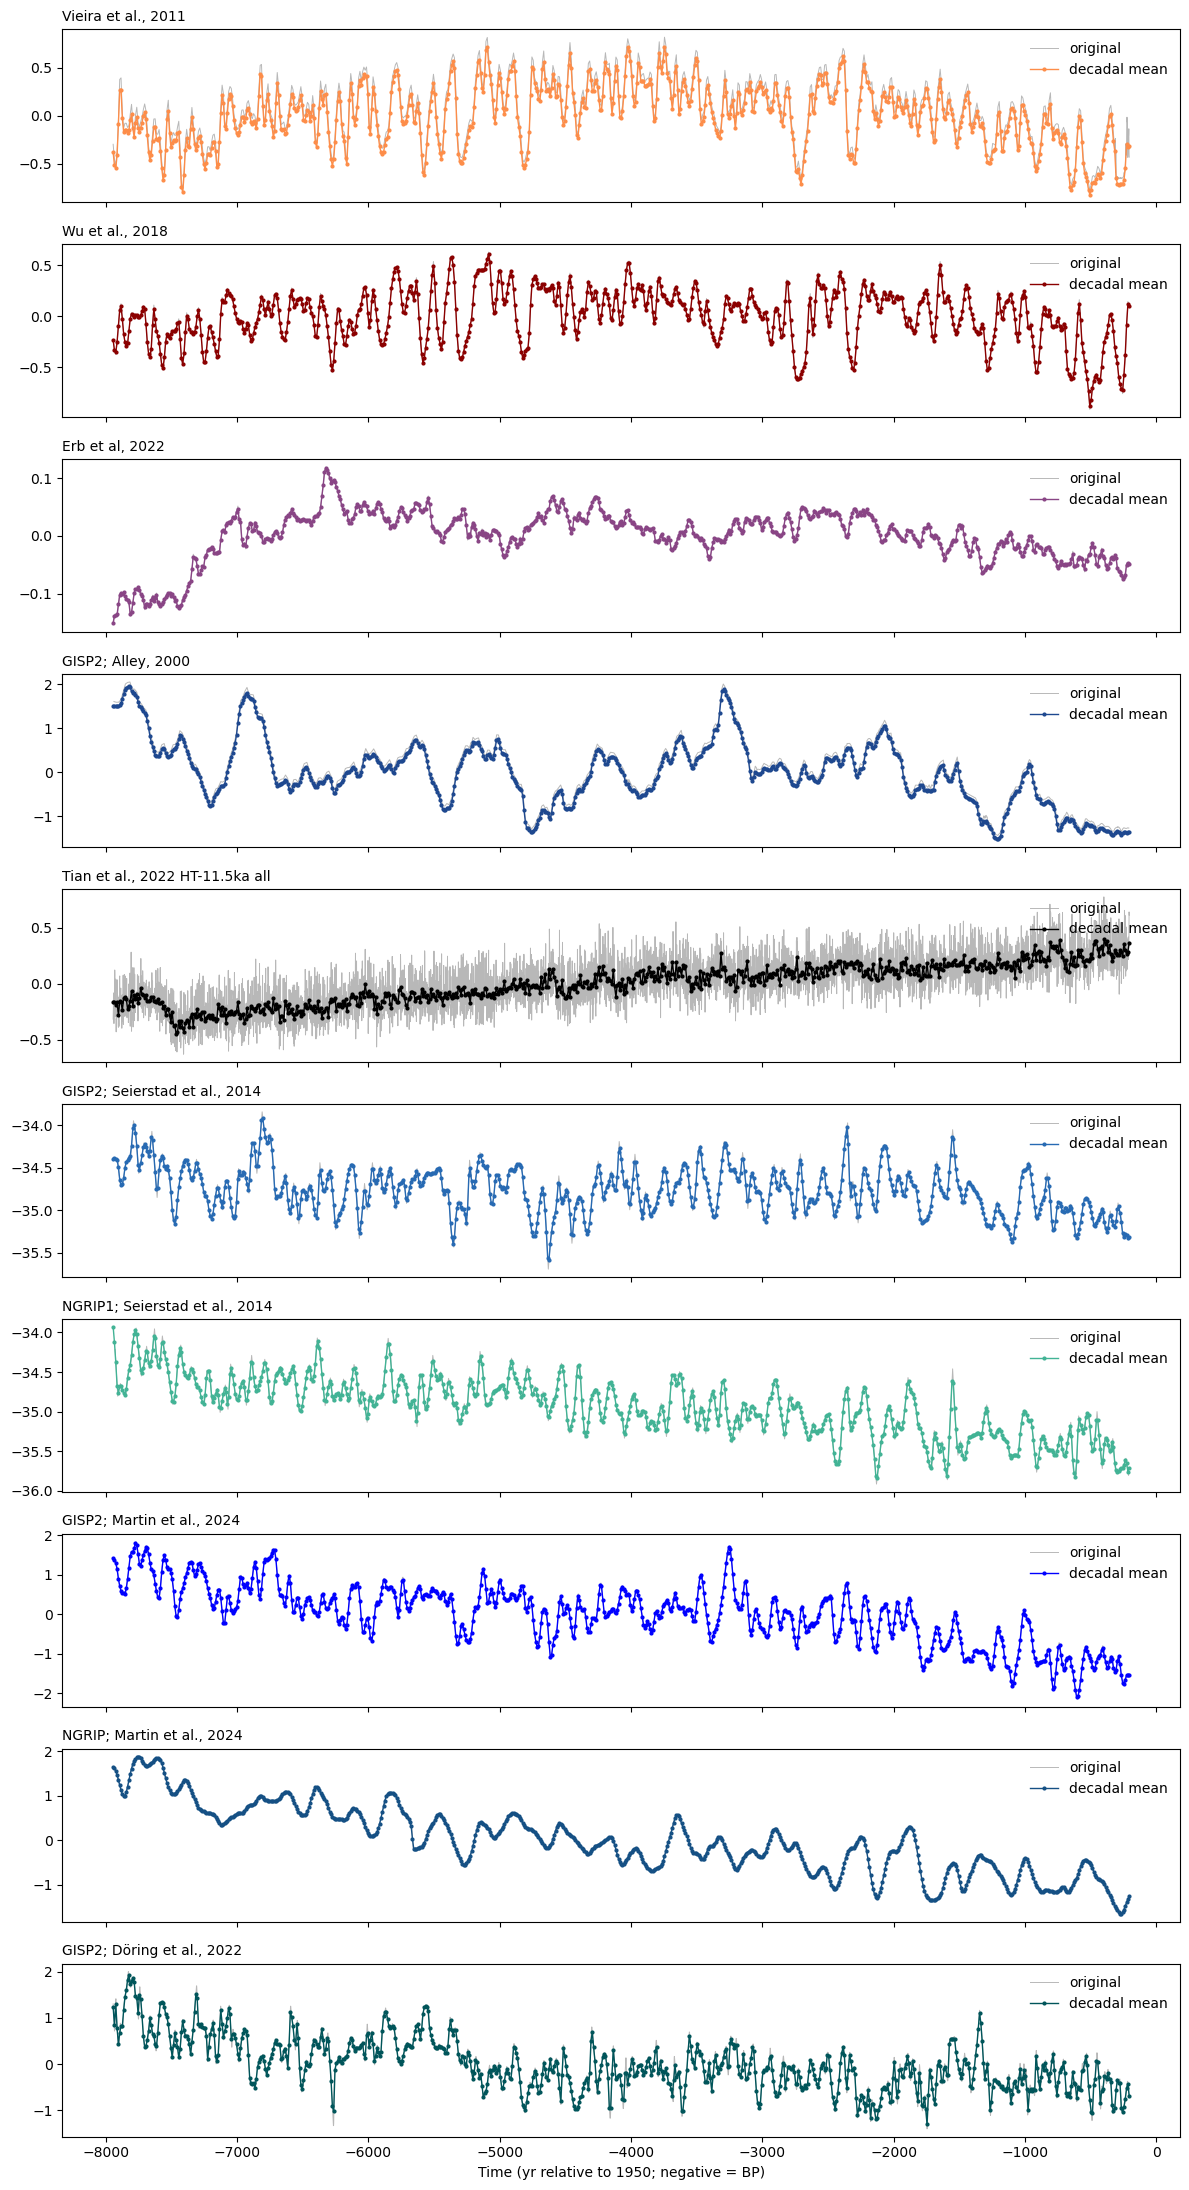

In [67]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(nrows=len(var_objects), ncols=1, figsize=(12, 2.2 * len(var_objects)), sharex=True)
axes = np.atleast_1d(axes)

for axis, (var_id, var_object) in zip(axes, var_objects.items()):
    source_series = original_series[var_id]
    source_time = source_series[var_object.time_var]
    in_window = source_time.between(-wu_decadal_time.max(), -wu_decadal_time.min())
    mean_offset = source_series.loc[in_window, var_object.col_name].mean() if 'd18O' not in var_id else 0

    axis.plot(source_time[in_window], source_series.loc[in_window, var_object.col_name]-mean_offset, color='0.65', linewidth=0.7, alpha=0.8, label='original')
    axis.plot(var_object.ts[var_object.time_var], var_object.ts[var_object.col_name], color=var_object.color, marker='o', markersize=2, linewidth=1.0, label='decadal mean')
    axis.set_title(var_object.var_label or var_id, loc="left", fontsize=10)
    axis.legend(loc="upper right", frameon=False)

axes[-1].set_xlabel('Time (yr relative to 1950; negative = BP)')
figure.tight_layout()


The decadal series tracks the original closely; some records lose a small amount
of amplitude to binning, but not enough to call the two series identical.

### Write to `master_data`

In [68]:
# Inspect and optionally save the current decadal VarObjects.
# This cell is intentionally commented out. Review the printed names before
# uncommenting the loop; it writes each current `var_object.ts` to master_data.
#
master_data_path = proj_stem/'master_data'
for var_id, var_object in var_objects.items():
    output_path = master_data_path / f"{var_object.real_ts_csv}.csv"
    print(f"{var_id}")
    print(f"  real CSV:   {output_path.name}")
    print(f"  value var:  {var_object.col_name}")
    print(f"  time var:   {var_object.time_var}")
    # var_object.ts.to_csv(output_path, index=False)


Vieira11TSI
  real CSV:   vieira_TSI.csv
  value var:  vieira_tsi
  time var:   time
Wu18TSI
  real CSV:   wu_TSI.csv
  value var:  wu_tsi
  time var:   time
Erb22daGMST
  real CSV:   erb_temp.csv
  value var:  erb2022_da_temp
  time var:   time
GISP2Alley00Tanom
  real CSV:   GISP2multiproxy_temp.csv
  value var:  Alley_multiproxy_temp
  time var:   time
Tian22HT115kaALLGMST
  real CSV:   tian22_ht115kaallgmst_temp.csv
  value var:  tian22ht115kaallgmst
  time var:   time
GISP2Seierstad14d18O
  real CSV:   Seierstad_2014_GISP2_d18O_decavg_d18O.csv
  value var:  GISP2seierstad14d18O_decavg_d18O
  time var:   time
NGRIP1Seierstad14d18O
  real CSV:   Seierstad_2014_NGRIP1_d18O_decavg_d18O.csv
  value var:  NGRIP1seierstad14d18O_decavg_d18O
  time var:   time
GISP2Martin24Tanom
  real CSV:   Martin_2024_GISP2_Tanom_decavg_temp.csv
  value var:  GISP2martin24Tanom_decavg_temp
  time var:   time
NGRIPMartin24Tanom
  real CSV:   Martin_2024_NGRIP_Tanom_decavg_temp.csv
  value var:  NGRIPmart

# Surrogates

Phase-randomized surrogates (Prichard & Theiler, 1994) are what CCM's significance
test is built on (Methods: *Workflow*; Supplement Text S1.3). Randomize a series'
phase spectrum while keeping its power spectrum fixed, and you break any real
temporal relationship to the paired series but keep the surrogate's autocorrelation
structure realistic — so a "surrogate relationship" shows what CCM skill would look
like from coincidence alone, given the same spectral content. Later notebooks compare
the real relationship's final ρ against the 95th percentile of final ρ across 200
surrogates of each variable (400 total per configuration) to decide whether a
configuration clears the significance bar.


In [69]:
import pyleoclim as pyleo

n_surrogates = 500
surrogate_method = 'phaseran'
surrogate_seed = 20260811
np.random.seed(surrogate_seed)

surrogate_sets = {}
for var_id, var_object in var_objects.items():
    # Replace the current series with the explicit all-record intersection.
    var_object.ts = common_decadal_df[['time', var_id]].rename(
        columns={'time': var_object.time_var, var_id: var_object.col_name}
    ).copy()

    surrogate_set = pyleo.SurrogateSeries(
        method=surrogate_method, number=n_surrogates
    )
    surrogate_set.from_series(var_object.ps)
    surrogate_sets[var_id] = surrogate_set

### Write to `master_surrogates`

In [70]:
# This cell is intentionally commented out. It writes one wide CSV per
# VarObject to master_surrogates, using its configured surrogate stem when
# available and otherwise a conventional pyleo_surr_<real-stem> fallback.
#
master_surrogates_path = proj_stem / 'master_surrogates'
master_surrogates_path.mkdir(parents=True, exist_ok=True)

for var_id, surrogate_set in surrogate_sets.items():
    var_object = var_objects[var_id]
    surrogate_frame = pd.DataFrame({
        var_object.surr_ts_time: var_object.ts[var_object.time_var].to_numpy(),
    })
    for number, surrogate in enumerate(surrogate_set.series_list, start=1):
        surrogate_frame[f'{var_object.surr_prefix}_{number}'] = surrogate.value

    output_stem = var_object.surr_ts_csv or f'pyleo_surr_{var_object.real_ts_csv}'
    output_path = master_surrogates_path / f'{output_stem}.csv'
    print(f'{var_id}: {output_path.name}')
    # surrogate_frame.to_csv(output_path, index=False)

Vieira11TSI: pyleo_surr_vieira_TSI.csv
Wu18TSI: pyleo_surr_wu_TSI.csv
Erb22daGMST: pyleo_surr_erb_temp.csv
GISP2Alley00Tanom: pyleo_surr_GISP2multiproxy_temp.csv
Tian22HT115kaALLGMST: pyleo_surr_tian22_ht115kaallgmst_temp.csv
GISP2Seierstad14d18O: pyleo_surr_Seierstad_2014_GISP2_d18O_decavg_d18O.csv
NGRIP1Seierstad14d18O: pyleo_surr_Seierstad_2014_NGRIP1_d18O_decavg_d18O.csv
GISP2Martin24Tanom: pyleo_surr_Martin_2024_GISP2_Tanom_decavg_temp.csv
NGRIPMartin24Tanom: pyleo_surr_Martin_2024_NGRIP_Tanom_decavg_temp.csv
GISP2Doering22T15N: pyleo_surr_Doering_2022_A_T15N_goujon_decavg_temp.csv
